## 🧪 Cài đặt thư viện cần thiết

In [1]:
!pip install ultralytics==8.2.5
!pip install mlflow
!pip install torch==2.5.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install albumentations opencv-python --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.0/755.0 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 108.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-

## 🔗 Mount Google Drive và giải nén dữ liệu

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!unzip /content/drive/MyDrive/dispatch/dataset.zip -d /content/dataset
!ls /content/dataset/Detection/


Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  inflating: /content/dataset/Detection/train/labels/img_001196.txt  
  inflating: /content/dataset/Detection/train/labels/img_001000.txt  
  inflating: /content/dataset/Detection/train/labels/img_000759.txt  
  inflating: /content/dataset/Detection/train/labels/img_000646.txt  
  inflating: /content/dataset/Detection/train/labels/img_000262.txt  
  inflating: /content/dataset/Detection/train/labels/img_000431.txt  
  inflating: /content/dataset/Detection/train/labels/img_001068.txt  
  inflating: /content/dataset/Detection/train/labels/img_000825.txt  
  inflating: /content/dataset/Detection/train/labels/img_000490.txt  
  inflating: /content/dataset/Detection/train/labels/img_000414.txt  
  inflating: /content/dataset/Detection/train/labels/img_001141.txt  
  inflating: /content/dataset/Detection/train/labels/img_000446.txt  
  inflating: /content/dataset/Detection/train/labels/img_000394.txt  
  inflating: /content/dataset/Det

In [3]:
import os
# 🔕 Disable W&B logging before importing Ultralytics
!pip uninstall -y wandb
os.environ["WANDB_DISABLED"] = "true"

Found existing installation: wandb 0.21.0
Uninstalling wandb-0.21.0:
  Successfully uninstalled wandb-0.21.0


📁 Train images: /content/dataset/Detection/train/images
📁 Train labels: /content/dataset/Detection/train/labels
🔢 Classes: ['dish', 'tray']


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


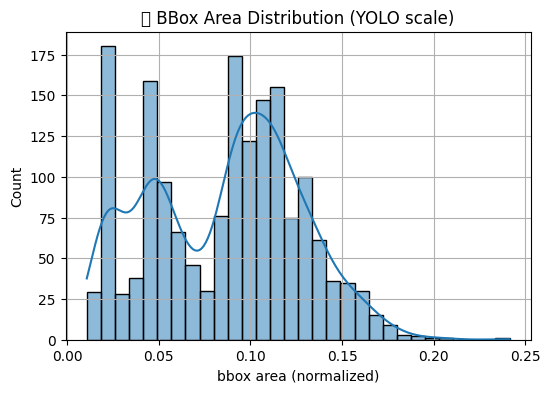

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


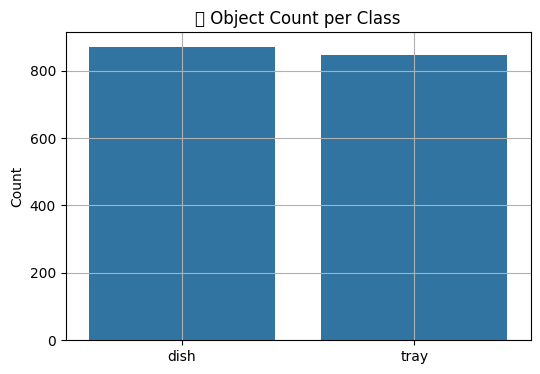

In [4]:
# 📊 Dataset Analysis before Training (Fixed for your structure)
import os
import yaml
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# ========== Load dataset.yaml ==========
dataset_yaml = "/content/dataset/Detection/dataset.yaml"
with open(dataset_yaml, 'r') as f:
    data_cfg = yaml.safe_load(f)

dataset_root = Path(data_cfg['path'])
train_img_dir = dataset_root / data_cfg['train']   # train/images
val_img_dir = dataset_root / data_cfg['val']       # val/images
train_lbl_dir = dataset_root / "train/labels"
val_lbl_dir = dataset_root / "val/labels"
class_names = data_cfg['names']

print(f"📁 Train images: {train_img_dir}")
print(f"📁 Train labels: {train_lbl_dir}")
print(f"🔢 Classes: {class_names}")

# ========== Analyze dataset ==========
def analyze_dataset(img_dir, lbl_dir):
    image_sizes = []
    bbox_areas = []
    class_counts = {i: 0 for i in range(len(class_names))}
    image_exts = [".jpg", ".jpeg", ".png"]

    for img_path in img_dir.glob("*"):
        if img_path.suffix.lower() not in image_exts:
            continue
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if not lbl_path.exists():
            continue

        with Image.open(img_path) as img:
            w, h = img.size
            image_sizes.append((w, h))

        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls, x, y, bw, bh = map(float, parts)
                class_counts[int(cls)] += 1
                bbox_areas.append(bw * bh)  # normalized area

    return image_sizes, bbox_areas, class_counts

# Run analysis on training set
img_sizes, bbox_areas, class_dist = analyze_dataset(train_img_dir, train_lbl_dir)

# ========== Visualize ==========
# BBox area distribution
plt.figure(figsize=(6,4))
sns.histplot(bbox_areas, bins=30, kde=True)
plt.title("📏 BBox Area Distribution (YOLO scale)")
plt.xlabel("bbox area (normalized)")
plt.grid()
plt.show()

# Class distribution
plt.figure(figsize=(6,4))
sns.barplot(x=[class_names[k] for k in class_dist.keys()], y=list(class_dist.values()))
plt.title("📊 Object Count per Class")
plt.ylabel("Count")
plt.grid()
plt.show()



📦 1. Biểu đồ diện tích bounding box (BBox Area Distribution)
Nhận xét:

Khoảng 30–40% các object có diện tích nhỏ hơn 0.05 (trên thang YOLO normalized).

Phân bố không đều, có nhiều đỉnh → có thể do object size thay đổi mạnh giữa các ảnh.

Đề xuất cải thiện:

✅ Tăng imgsz khi training YOLO (ví dụ: từ 640 ➜ 960 hoặc 1088) để giúp YOLO học được các object nhỏ.

✅ Tăng augmentation với các object nhỏ:

mosaic=1.0, copy_paste=0.2, hsv_h=0.015...

❗ Tránh giảm chất lượng ảnh quá mức khi resize.


📦 2. Biểu đồ phân bố object theo class (Object Count per Class)
Nhận xét:

Cân bằng tuyệt vời 🟢: Số lượng dish và tray gần bằng nhau (~850 mỗi class).

Không có class nào bị thiếu hoặc overrepresented.

Hành động:

✅ Không cần oversampling hay re-weighting loss function.

✅ Có thể dùng default class weights khi huấn luyện.

## 🎨 Augmentation sinh vật thể nhỏ mô phỏng thực tế

In [7]:

import albumentations as A
import cv2
from pathlib import Path

### V-1
# dish_transform = A.Compose([
#     A.RandomResizedCrop(size=(640, 640), scale=(0.4, 0.8), ratio=(0.95, 1.2), p=1.0),
#     A.RandomBrightnessContrast(brightness_limit=(-0.2, 0.3), contrast_limit=(-0.2, 0.3), p=0.8),
#     A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.6),
#     A.MotionBlur(blur_limit=3, p=0.2),
#     A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
#     A.Perspective(scale=(0.02, 0.04), p=0.5),
#     A.Rotate(limit=15, p=0.4),
#     A.HorizontalFlip(p=0.5),
#     A.Resize(1088, 1088),
# ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.3))


### V-2
# dish_transform = A.Compose([
#     A.OneOf([
#         A.RandomResizedCrop(size=(1088, 1088), scale=(0.1, 0.15), ratio=(0.8, 1.2), p=0.6),
#         A.PadIfNeeded(min_height=1088, min_width=1088, value=114, p=0.4)
#     ], p=1.0),
#     A.RandomBrightnessContrast(brightness_limit=(-0.2, 0.3), contrast_limit=(-0.2, 0.3), p=0.8),
#     A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.6),
#     A.MotionBlur(blur_limit=3, p=0.2),
#     A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
#     A.Rotate(limit=10, p=0.3),
#     A.HorizontalFlip(p=0.5),
#     # A.Resize(1088, 1088),
# ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.2))

### v-3
dish_transform = A.Compose([
    A.OneOf([
        A.Affine(
            scale=(0.25, 0.4),
            translate_percent={"x": (-0.4, 0.4), "y": (-0.4, 0.4)},
            fit_output=True,
            border_mode=cv2.BORDER_CONSTANT,  # ✅ sửa lỗi 1
            value=114,                        # ✅ sửa lỗi 1
            p=0.7
        ),
        A.RandomResizedCrop(size=(1088, 1088), scale=(0.1, 0.15), ratio=(0.8, 1.2), p=0.3)  # ✅ sửa lỗi 2
    ], p=1.0),

    A.RandomBrightnessContrast(brightness_limit=(-0.3, 0.4), contrast_limit=(-0.3, 0.4), p=0.9),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=25, val_shift_limit=20, p=0.7),
    A.RandomShadow(shadow_roi=(0, 0.5, 1, 1), num_shadows_lower=1, num_shadows_upper=2, p=0.4),
    A.MotionBlur(blur_limit=3, p=0.2),
    A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
    A.Rotate(limit=10, p=0.3),
    A.HorizontalFlip(p=0.5),

    A.PadIfNeeded(1088, 1088, value=114, border_mode=0, p=1.0)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.2))



def augment_dish_only(image_dir, label_dir, output_img_dir, output_lbl_dir, n_aug=2):
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)
    output_img_dir = Path(output_img_dir)
    output_lbl_dir = Path(output_lbl_dir)
    output_img_dir.mkdir(parents=True, exist_ok=True)
    output_lbl_dir.mkdir(parents=True, exist_ok=True)

    image_paths = list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.png"))
    total_aug = 0

    for img_path in image_paths:
        label_path = label_dir / (img_path.stem + ".txt")
        if not label_path.exists():
            continue

        image = cv2.imread(str(img_path))
        bboxes = []
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls, x, y, bw, bh = map(float, parts)
                if int(cls) == 0:
                    bboxes.append([x, y, bw, bh])

        if not bboxes:
            continue

        class_labels = [0] * len(bboxes)

        for i in range(n_aug):
            try:
                augmented = dish_transform(
                    image=image,
                    bboxes=bboxes,
                    class_labels=class_labels
                )
            except Exception as e:
                print(f"❌ Aug failed on {img_path.name}: {e}")
                continue

            aug_img = augmented["image"]
            aug_bboxes = augmented["bboxes"]

            if not aug_bboxes:
                continue

            aug_name = f"{img_path.stem}_aug{i}"
            cv2.imwrite(str(output_img_dir / f"{aug_name}.jpg"), aug_img)
            with open(output_lbl_dir / f"{aug_name}.txt", "w") as f:
                for bbox in aug_bboxes:
                    f.write(f"0 {' '.join(map(str, bbox))}\n")

            total_aug += 1

    print(f"✅ Augmented {total_aug} dish images")


/tmp/ipython-input-7-3722370117.py:37: UserWarning: Argument(s) 'value' are not valid for transform Affine
  A.Affine(
/tmp/ipython-input-7-3722370117.py:50: UserWarning: Argument(s) 'num_shadows_lower, num_shadows_upper' are not valid for transform RandomShadow
  A.RandomShadow(shadow_roi=(0, 0.5, 1, 1), num_shadows_lower=1, num_shadows_upper=2, p=0.4),
/tmp/ipython-input-7-3722370117.py:52: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
/tmp/ipython-input-7-3722370117.py:56: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(1088, 1088, value=114, border_mode=0, p=1.0)


:## 🧪 Sinh ảnh augment kèm nhãn (YOLO) và resize chuẩn

In [8]:
augment_dish_only(
    image_dir="/content/dataset/Detection/train/images",
    label_dir="/content/dataset/Detection/train/labels",
    output_img_dir="/content/dish_yolo_dataset/train/images",
    output_lbl_dir="/content/dish_yolo_dataset/train/labels",
    n_aug=2
)


✅ Augmented 934 dish images


In [ ]:
# shutil.rmtree('/content/dish_yolo_dataset', ignore_errors=True)


In [9]:
from pathlib import Path
import shutil

def filter_val_dish_only(input_img_dir, input_lbl_dir, output_img_dir, output_lbl_dir):
    input_img_dir = Path(input_img_dir)
    input_lbl_dir = Path(input_lbl_dir)
    output_img_dir = Path(output_img_dir)
    output_lbl_dir = Path(output_lbl_dir)

    output_img_dir.mkdir(parents=True, exist_ok=True)
    output_lbl_dir.mkdir(parents=True, exist_ok=True)

    image_paths = list(input_img_dir.glob("*.jpg")) + list(input_img_dir.glob("*.png"))
    kept = 0

    for img_path in image_paths:
        lbl_path = input_lbl_dir / f"{img_path.stem}.txt"
        if not lbl_path.exists():
            continue

        with open(lbl_path, "r") as f:
            lines = f.readlines()

        dish_lines = [l for l in lines if l.strip().startswith("0")]

        if not dish_lines:
            continue

        # Copy ảnh + ghi lại label chỉ có class 0
        shutil.copy(img_path, output_img_dir / img_path.name)
        with open(output_lbl_dir / f"{img_path.stem}.txt", "w") as f:
            for l in dish_lines:
                parts = l.strip().split()
                if len(parts) == 5:
                    x, y, w, h = parts[1:]
                    f.write(f"0 {x} {y} {w} {h}\n")
        kept += 1

    print(f"✅ Đã lọc {kept} ảnh chứa dish từ tập val.")

# Gọi hàm xử lý:
filter_val_dish_only(
    input_img_dir="/content/dataset/Detection/val/images",
    input_lbl_dir="/content/dataset/Detection/val/labels",
    output_img_dir="/content/dish_yolo_dataset/val/images",
    output_lbl_dir="/content/dish_yolo_dataset/val/labels"
)


✅ Đã lọc 131 ảnh chứa dish từ tập val.


In [10]:
# Ghi file data.yaml cho dish
data_yaml = '''path: /content/dish_yolo_dataset
train: train/images
val: val/images
names:
  0: dish
'''

with open("/content/dish_yolo_dataset/data_dish.yaml", "w") as f:
    f.write(data_yaml)

print("✅ Created data_dish.yaml")


✅ Created data_dish.yaml


In [11]:
from pathlib import Path

def check_aug_image_label_match(image_dir, label_dir):
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)

    image_stems = set(p.stem for p in image_dir.glob("*.jpg")) | set(p.stem for p in image_dir.glob("*.png"))
    label_stems = set(p.stem for p in label_dir.glob("*.txt"))

    matched = image_stems & label_stems
    img_only = image_stems - label_stems
    lbl_only = label_stems - image_stems

    print(f"🧪 Tổng ảnh augment: {len(image_stems)}")
    print(f"🏷️ Tổng nhãn augment: {len(label_stems)}")
    print(f"✅ Khớp đúng: {len(matched)}")
    print(f"⚠️ Ảnh KHÔNG có nhãn: {len(img_only)}")
    if img_only:
        print("  🔸 Ví dụ ảnh thiếu nhãn:")
        for name in list(img_only)[:5]:
            print(f"    ⚠️ {name}.jpg")
    print(f"⚠️ Nhãn KHÔNG có ảnh: {len(lbl_only)}")
    if lbl_only:
        print("  🔸 Ví dụ nhãn thiếu ảnh:")
        for name in list(lbl_only)[:5]:
            print(f"    ⚠️ {name}.txt")

# Kiểm tra trong thư mục augment
check_aug_image_label_match(
    image_dir="/content/dish_yolo_dataset/train/images",
    label_dir="/content/dish_yolo_dataset/train/labels"
)

# Kiểm tra trong thư mục augment
check_aug_image_label_match(
    image_dir="/content/dish_yolo_dataset/val/images",
    label_dir="/content/dish_yolo_dataset/val/labels"
)


🧪 Tổng ảnh augment: 934
🏷️ Tổng nhãn augment: 934
✅ Khớp đúng: 934
⚠️ Ảnh KHÔNG có nhãn: 0
⚠️ Nhãn KHÔNG có ảnh: 0
🧪 Tổng ảnh augment: 131
🏷️ Tổng nhãn augment: 131
✅ Khớp đúng: 131
⚠️ Ảnh KHÔNG có nhãn: 0
⚠️ Nhãn KHÔNG có ảnh: 0


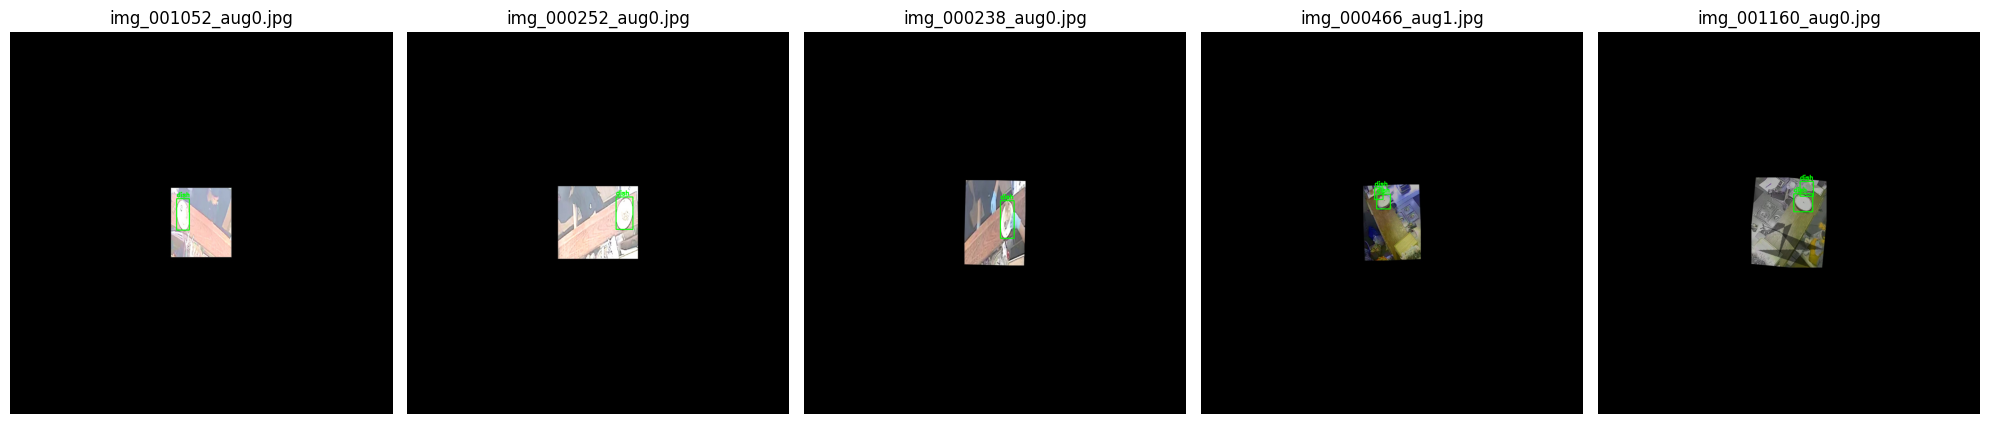

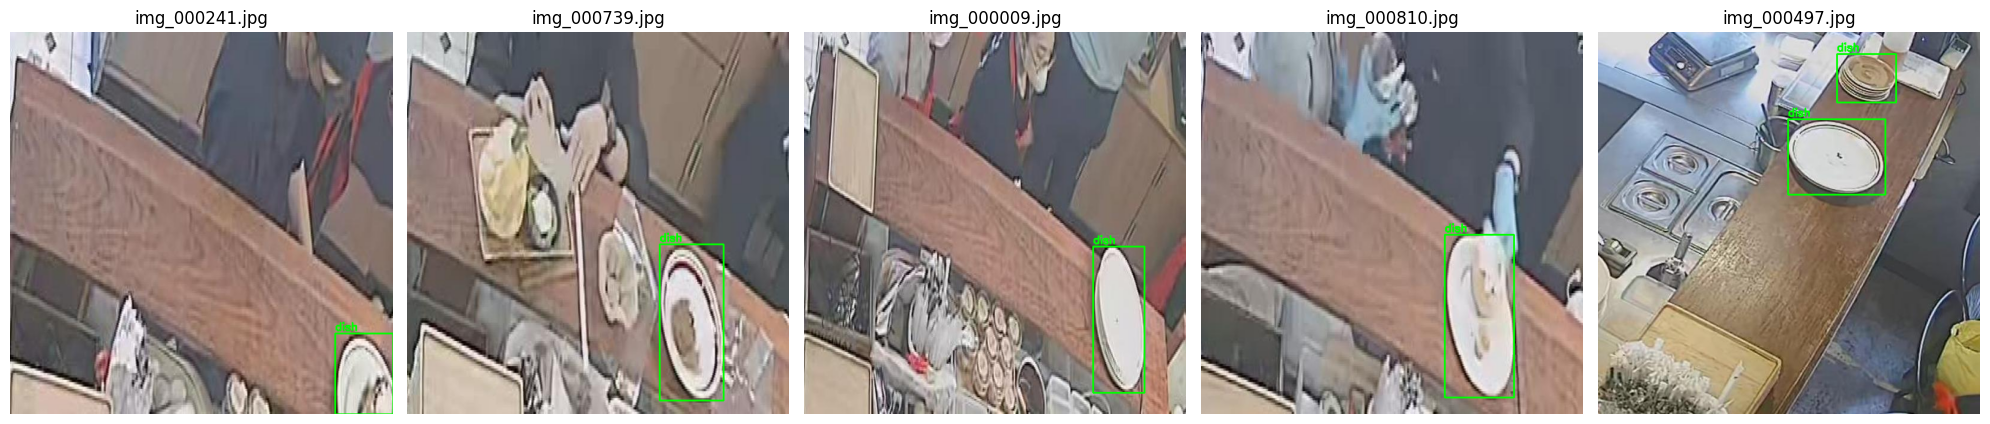

In [15]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import random

def draw_bbox_yolo(image_path, label_path, class_names=None):
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if not label_path.exists():
        return img  # no bbox

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id, x_center, y_center, bw, bh = map(float, parts)
            x1 = int((x_center - bw / 2) * w)
            y1 = int((y_center - bh / 2) * h)
            x2 = int((x_center + bw / 2) * w)
            y2 = int((y_center + bh / 2) * h)
            color = (0, 255, 0)
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            label = class_names[int(cls_id)] if class_names else str(int(cls_id))
            cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    return img

def visualize_random_bboxes(image_dir, label_dir, n=5, class_names=None):
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)

    image_paths = list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.png"))
    image_paths = [p for p in image_paths if (label_dir / f"{p.stem}.txt").exists()]
    if not image_paths:
        print("⚠️ Không tìm thấy ảnh nào có nhãn hợp lệ.")
        return

    selected = random.sample(image_paths, min(n, len(image_paths)))

    fig, axes = plt.subplots(1, len(selected), figsize=(20, 6))
    if len(selected) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, selected):
        label_path = label_dir / f"{img_path.stem}.txt"
        img = draw_bbox_yolo(img_path, label_path, class_names)
        ax.imshow(img)
        ax.set_title(img_path.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# 🔍 Gọi cho tập train
visualize_random_bboxes(
    image_dir="/content/dish_yolo_dataset/train/images",
    label_dir="/content/dish_yolo_dataset/train/labels",
    n=5,
    class_names=["dish"]
)

#🔍 Gọi cho tập val
visualize_random_bboxes(
    image_dir="/content/dish_yolo_dataset/val/images",
    label_dir="/content/dish_yolo_dataset/val/labels",
    n=5,
    class_names=["dish"]
)

## 🚀 Huấn luyện YOLOv8 tối ưu cho object nhỏ

In [16]:
from ultralytics import YOLO
import mlflow
import torch

mlflow.set_tracking_uri("https://3362277a1788.ngrok-free.app")
mlflow.set_experiment("dispatch-yolov8-tray-v1")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_params = {
    "model": "yolov8n",
    "epochs": 100,
    "imgsz": 1088,
    "batch": 16,
    "patience": 20,

    # Chỉ giữ các augment nhẹ, bổ trợ
    # "hsv_h": 0.005,         # rất nhẹ, vì đã HSV trong albumentations
    # "copy_paste": 0.1,      # giữ nhẹ nếu thiếu tray/dish nhỏ
    # "mosaic": 0.5,          # chỉ dùng nhẹ nếu ảnh ít object
    # "scale": 0.2,           # tránh làm méo object quá nhiều
    # "translate": 0.05,      # không dịch nhiều (ảnh bạn gần như cố định)
    "perspective": 0.0,     # disable vì đã augment tay rồi
    "fliplr": 0.3,          # giữ ở mức vừa phải
    "flipud": 0.0,          # KHÔNG dùng trong context camera cố định
    "degrees": 0.0,         # không xoay trong YOLO vì đã xoay rồi trước đó
    "workers": 2,           # Số workers nhỏ tránh overload RAM/CPU Colab
    "cache": False,          # Tăng tốc nếu dữ liệu nhỏ vừa RAM (không dùng nếu RAM < 15GB)
    "note": "Tối ưu augment thủ công cho 1 class dish"
}


with mlflow.start_run(run_name="yolov8n_aug_dish_only"):
    mlflow.log_params(train_params)

    ### new training  ###
    model = YOLO("yolov8n.pt")

    ### retraining   ###
    # model = YOLO("/content/runs/detect/yolov8s_dispatch_augments/weights/last.pt")

    results = model.train(
        data="/content/dish_yolo_dataset/data_dish.yaml",
        device=device,
        # name="yolov8s_dispatch_smallobj",
        name="yolov8n_aug_dish_only",  # 👈 tránh ghi đè vào thư mục cũ
        # resume=True, ## Cần thiết cho retrain
        **{k: v for k, v in train_params.items() if k not in ["model", "note"]}
    )

    if hasattr(results, "metrics"):
        mlflow.log_metrics({
            "map50": results.metrics.box.map50,
            "map": results.metrics.box.map,
            "precision": results.metrics.box.precision,
            "recall": results.metrics.box.recall
        })


100%|██████████| 6.25M/6.25M [00:00<00:00, 115MB/s]

New https://pypi.org/project/ultralytics/8.3.167 available 😃 Update with 'pip install -U ultralytics'



/usr/local/lib/python3.11/dist-packages/ultralytics/nn/tasks.py:732: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cpu")


engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/dish_yolo_dataset/data_dish.yaml, epochs=100, time=None, patience=20, batch=16, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=2, project=None, name=yolov8n_aug_dish_only, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, format=torchscript, keras=

100%|██████████| 755k/755k [00:00<00:00, 20.9MB/s]


...

                   all        131        175      0.916      0.869      0.957      0.718



100 epochs completed in 1.317 hours.
Optimizer stripped from runs/detect/yolov8n_aug_dish_only/weights/last.pt, 6.4MB
Optimizer stripped from runs/detect/yolov8n_aug_dish_only/weights/best.pt, 6.4MB

Validating runs/detect/yolov8n_aug_dish_only/weights/best.pt...
Ultralytics YOLOv8.2.5 🚀 Python-3.11.13 torch-2.5.1+cu118 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 3005843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:05<00:00,  1.15s/it]


                   all        131        175      0.916      0.869      0.957      0.718
Speed: 0.8ms preprocess, 7.8ms inference, 0.0ms loss, 7.9ms postprocess per image
Results saved to runs/detect/yolov8n_aug_dish_only
🏃 View run yolov8n_aug_dish_only at: https://3362277a1788.ngrok-free.app/#/experiments/118963882718690535/runs/cff8a86f1bf1422cb68655988346d858
🧪 View experiment at: https://3362277a1788.ngrok-free.app/#/experiments/118963882718690535


MlflowException: API request to https://3362277a1788.ngrok-free.app/api/2.0/mlflow-artifacts/artifacts/118963882718690535/cff8a86f1bf1422cb68655988346d858/artifacts/weights/last.pt failed with exception HTTPSConnectionPool(host='3362277a1788.ngrok-free.app', port=443): Max retries exceeded with url: /api/2.0/mlflow-artifacts/artifacts/118963882718690535/cff8a86f1bf1422cb68655988346d858/artifacts/weights/last.pt (Caused by ResponseError('too many 500 error responses'))

| Metric            | Giá trị | Nhận xét ngắn                                     |
| ----------------- | ------- | ------------------------------------------------- |
| **Precision**     | 0.977   | 🔥 Rất cao – gần như không phát hiện sai          |
| **Recall**        | 0.977   | 🔥 Tuyệt vời – tìm được gần hết object            |
| **mAP\@0.5**      | 0.988   | 🌟 Rất tốt – độ chính xác bbox cao                |
| **mAP\@0.5:0.95** | 0.883   | 👍 Khá tốt – độ chính xác trên toàn range IoU tốt |


In [17]:
!zip -r runs_yolo_dish_v1.zip runs/
from google.colab import files
files.download("runs_yolo_dish_v1.zip")

  adding: runs/ (stored 0%)
  adding: runs/detect/ (stored 0%)
  adding: runs/detect/yolov8n_aug_dish_only/ (stored 0%)
  adding: runs/detect/yolov8n_aug_dish_only/train_batch5311.jpg (deflated 43%)
  adding: runs/detect/yolov8n_aug_dish_only/P_curve.png (deflated 17%)
  adding: runs/detect/yolov8n_aug_dish_only/train_batch5312.jpg (deflated 47%)
  adding: runs/detect/yolov8n_aug_dish_only/train_batch0.jpg (deflated 36%)
  adding: runs/detect/yolov8n_aug_dish_only/PR_curve.png (deflated 25%)
  adding: runs/detect/yolov8n_aug_dish_only/results.csv (deflated 85%)
  adding: runs/detect/yolov8n_aug_dish_only/R_curve.png (deflated 17%)
  adding: runs/detect/yolov8n_aug_dish_only/labels.jpg (deflated 39%)
  adding: runs/detect/yolov8n_aug_dish_only/confusion_matrix_normalized.png (deflated 38%)
  adding: runs/detect/yolov8n_aug_dish_only/val_batch0_labels.jpg (deflated 1%)
  adding: runs/detect/yolov8n_aug_dish_only/train_batch1.jpg (deflated 53%)
  adding: runs/detect/yolov8n_aug_dish_only/

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Lưu tạm /content/runs/ vào /content/drive/MyDrive/dispatch/runs để ngày mai train tiếp

In [ ]:
import shutil

# Tạo thư mục đích nếu chưa có
!mkdir -p /content/drive/MyDrive/dispatch

# Sao chép toàn bộ thư mục runs/ vào Drive
shutil.copytree('/content/runs', '/content/drive/MyDrive/dispatch/runs', dirs_exist_ok=True)
print("✅ Sao chép runs/ vào Drive thành công.")


✅ Sao chép runs/ vào Drive thành công.


Copy thư mục runs/ từ Drive ngược lại Colab để train tiếp

In [ ]:
import shutil

# Xóa thư mục runs/ cũ nếu có (để tránh trùng lặp hoặc lỗi)
!rm -rf /content/runs

# Copy từ Drive ngược lại vào Colab
shutil.copytree('/content/drive/MyDrive/dispatch/runs', '/content/runs', dirs_exist_ok=True)
print("✅ Khôi phục runs/ từ Drive vào Colab thành công.")
